In [ ]:
pip install qiskit

In [ ]:
pip install qiskit-aer

In [ ]:
pip install matplotlib

In [ ]:
pip install pylatexenc

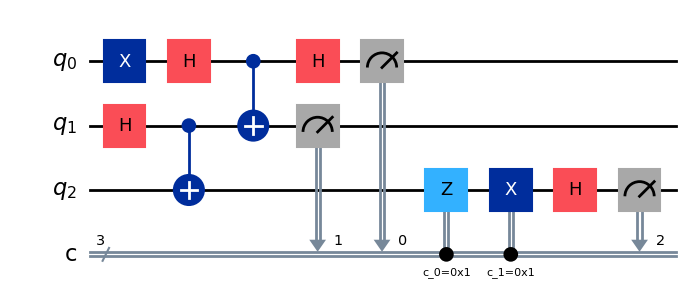

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit import transpile
from qiskit_aer import Aer

# Circuit and registers declaration
q_reg = QuantumRegister(3, 'q')
c_reg = ClassicalRegister(3, 'c')
circ = QuantumCircuit(q_reg, c_reg)

# Creation of the ket psi to be teleported
circ.x(q_reg[0])
circ.h(q_reg[0])

# Creation of the phi-plus entangled state
circ.h(q_reg[1])
circ.cx(q_reg[1], q_reg[2]) 

# Creation of the quantum teleportation circuit
circ.cx(q_reg[0], q_reg[1])
circ.h(q_reg[0])
circ.measure(q_reg[0], c_reg[0])
circ.measure(q_reg[1], c_reg[1])

# Performing measurements and checking the need to apply X and Z ports 
circ.z(q_reg[2]).c_if(c_reg[0], 1)  
circ.x(q_reg[2]).c_if(c_reg[1], 1)

# Undoing hadamard's state to get |1>
circ.h(q_reg[2])
circ.measure(q_reg[2], c_reg[2])

# Method to access the qiskit backend
Aer.backends()
backend = Aer.get_backend('qasm_simulator')
new_circuit = transpile(circ, backend)
job = backend.run(new_circuit)

circ.draw(output="mpl")


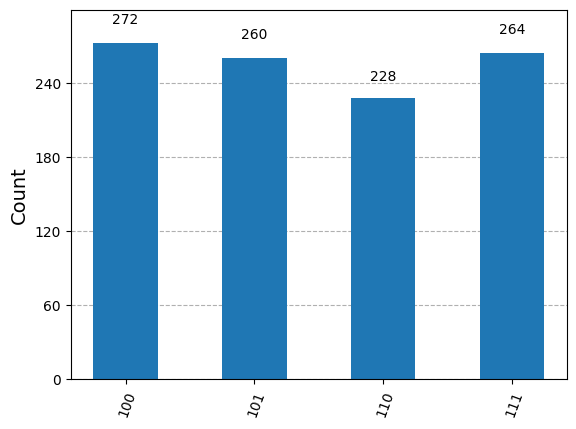

In [32]:
count = job.result().get_counts()
plot_histogram(count)